# **FingerVein dataset exploration (MMCBNU_6000)**
In this notebook we *only visualize* the **FingerVein** modality of our project, the [**MMCBNU_6000**](http://multilab.jbnu.ac.kr/) finger-vein database.

The dataset contains **6000 near-infrared images** of the finger-vein pattern, organized as:

`<subject 001..100> / <finger> / <01..10>.bmp`

with **100 subjects**, **6 fingers** each (left/right × fore/middle/ring) and **10 captures** per finger.

> **Note on age labels.** MMCBNU_6000 was released for finger-vein *recognition*, so the public package does **not** ship per-subject age. We will need the age annotations from the dataset's *Description* document (or an accompanying file) before training the age-regression model. This notebook focuses on inspecting the images.

# **Useful modules import**
We read the images directly from the `.zip` archive (no extraction needed) using `zipfile` and `Pillow`.

In [1]:
import io
import zipfile
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# **Configuration**
We point to the dataset archive. The datasets live next to the project, in `../proposal_helpers/proj_files/`. Adjust `DATA_ZIP_DIR` if you move them.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ZIP_DIR = PROJECT_ROOT.parent / 'proposal_helpers' / 'proj_files'
FV_ZIP = DATA_ZIP_DIR / 'MMCBNU_6000.zip'

assert FV_ZIP.exists(), f'FingerVein archive not found: {FV_ZIP}'
print('Using archive:', FV_ZIP)

Using archive: /Users/muni/Documents/uni/DL/proposal_helpers/proj_files/MMCBNU_6000.zip


# **Utility functions**
- **list_images** returns the list of `.bmp` entries inside the archive;
- **parse_path** extracts `(subject, finger, capture)` from an image path;
- **load_image** reads one `.bmp` from the archive into a NumPy array.

In [3]:
def list_images(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        return sorted(n for n in z.namelist() if n.lower().endswith('.bmp'))


def parse_path(name):
    # .../Captured images/<subject>/<finger>/<capture>.bmp
    parts = name.split('/')
    subject = parts[-3]
    finger = parts[-2]
    capture = parts[-1].replace('.bmp', '')
    return subject, finger, capture


def load_image(zip_path, name):
    with zipfile.ZipFile(zip_path) as z:
        return np.array(Image.open(io.BytesIO(z.read(name))))

# **Dataset overview**
Let's count images, subjects and fingers, and check a single image's shape.

In [4]:
images = list_images(FV_ZIP)
meta = [parse_path(n) for n in images]

subjects = sorted({m[0] for m in meta})
fingers = sorted({m[1] for m in meta})

print(f'Total images : {len(images)}')
print(f'Subjects     : {len(subjects)}  (e.g. {subjects[:5]} ...)')
print(f'Fingers      : {len(fingers)} -> {fingers}')

sample = load_image(FV_ZIP, images[0])
print(f'Image shape  : {sample.shape}  dtype={sample.dtype}  '
      f'min={sample.min()} max={sample.max()}')

Total images : 12000
Subjects     : 100  (e.g. ['001', '002', '003', '004', '005'] ...)
Fingers      : 6 -> ['L_Fore', 'L_Middle', 'L_Ring', 'R_Fore', 'R_Middle', 'R_Ring']
Image shape  : (480, 640)  dtype=uint8  min=0 max=225


# **A grid of finger-vein images**
We display the 6 fingers of a single subject to appreciate the vein patterns.

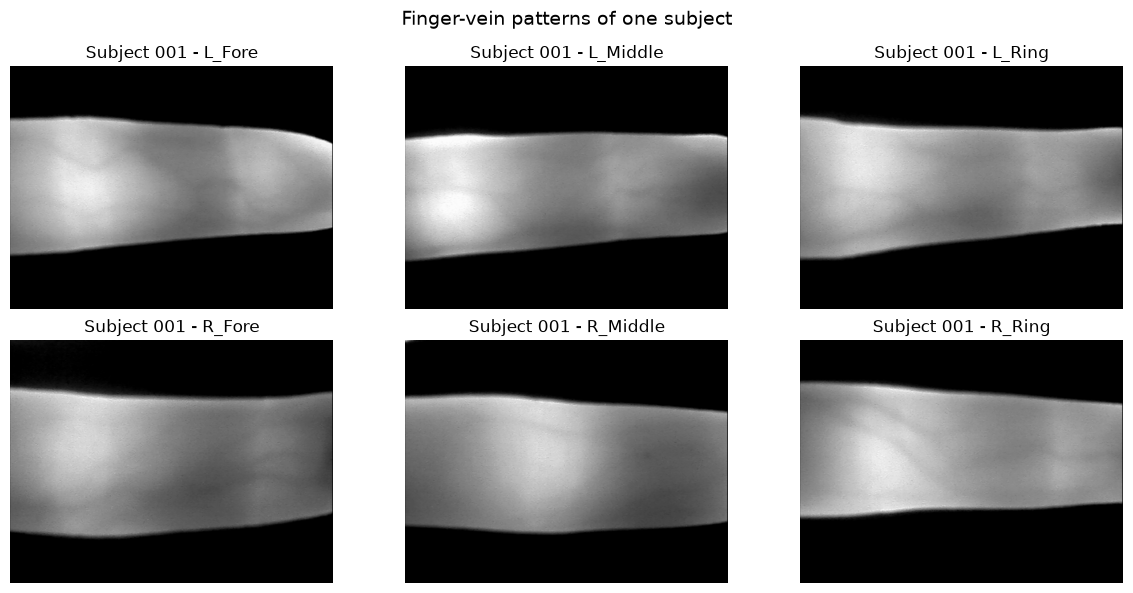

In [5]:
subject = subjects[0]
subject_imgs = [n for n in images if parse_path(n)[0] == subject]
# one image per finger
first_per_finger = {}
for n in subject_imgs:
    f = parse_path(n)[1]
    first_per_finger.setdefault(f, n)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (finger, name) in zip(axes.ravel(), sorted(first_per_finger.items())):
    ax.imshow(load_image(FV_ZIP, name), cmap='gray')
    ax.set_title(f'Subject {subject} - {finger}')
    ax.axis('off')
fig.suptitle('Finger-vein patterns of one subject', fontsize=14)
plt.tight_layout()
plt.show()

# **Same finger across different subjects**
Inter-subject variability of the vein pattern (this is what makes the modality biometric).

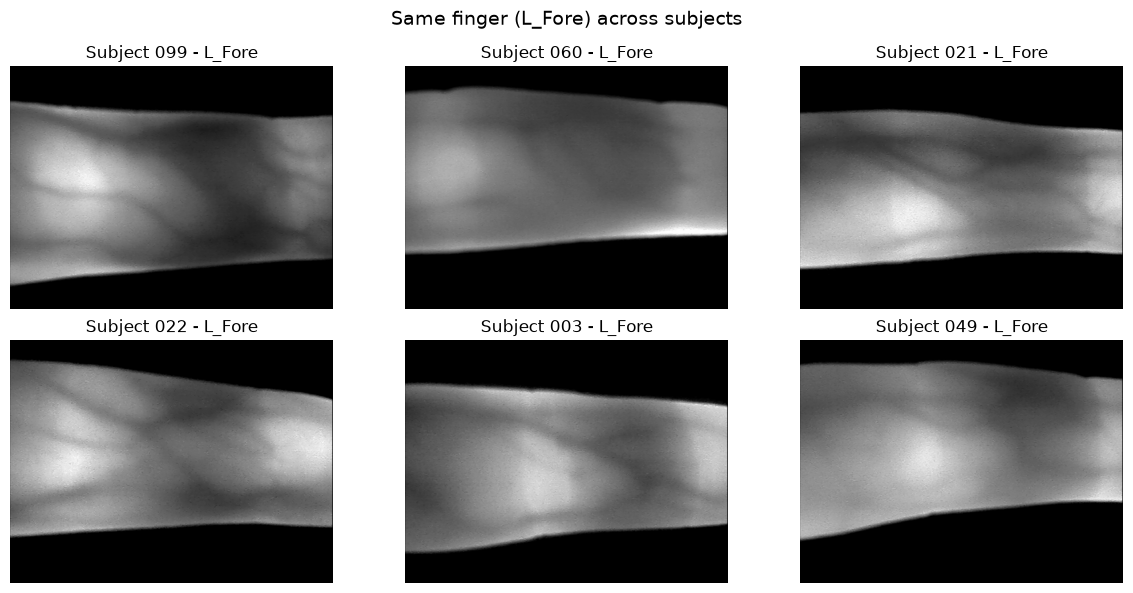

In [6]:
finger = fingers[0]
chosen = random.sample(subjects, 6)
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, subj in zip(axes.ravel(), chosen):
    name = next(n for n in images if parse_path(n)[:2] == (subj, finger))
    ax.imshow(load_image(FV_ZIP, name), cmap='gray')
    ax.set_title(f'Subject {subj} - {finger}')
    ax.axis('off')
fig.suptitle(f'Same finger ({finger}) across subjects', fontsize=14)
plt.tight_layout()
plt.show()

# **Pixel intensity distribution**
Understanding the illumination/contrast of the raw images helps design the preprocessing (ROI extraction, contrast normalization) described in the proposal.

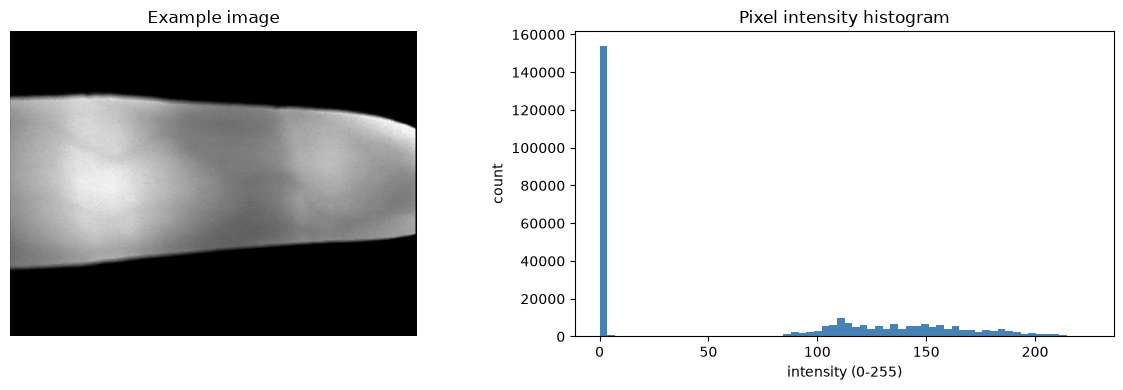

In [7]:
img = load_image(FV_ZIP, images[0])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(img, cmap='gray')
ax1.set_title('Example image')
ax1.axis('off')
ax2.hist(img.ravel(), bins=64, color='steelblue')
ax2.set_title('Pixel intensity histogram')
ax2.set_xlabel('intensity (0-255)')
ax2.set_ylabel('count')
plt.tight_layout()
plt.show()